# HELOC Stage 07: DiCE counterfactual explanations

This notebook applies DiCE to the frozen HELOC model and the fixed 20-case XAI cohort. The model, preprocessor, split, and cases are loaded from saved artifacts.

## 1. Setup and frozen inputs

The custom preprocessor definition is provided only for compatible artifact loading. No fitting or model training is performed.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib, json, time, traceback, warnings

import dice_ml
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, average_precision_score, balanced_accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.utils.validation import check_is_fitted

pd.set_option("display.max_columns", None); pd.set_option("display.width", 180)
plt.style.use("seaborn-v0_8-whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

class HELOCSpecialValuePreprocessor(BaseEstimator, TransformerMixin):
    """Median-impute HELOC measurements and append training-observed special-code indicators."""
    def __init__(self, feature_names, special_codes=(-7, -8, -9)):
        self.feature_names = feature_names; self.special_codes = special_codes
    def fit(self, X, y=None):
        frame = self._frame(X); self.feature_names_in_ = np.asarray(self.feature_names, dtype=object)
        self.indicator_pairs_ = [(feature, int(code)) for feature in self.feature_names for code in self.special_codes if frame[feature].eq(code).any()]
        numeric = frame[self.feature_names].mask(frame[self.feature_names].isin(self.special_codes))
        self.imputer_ = SimpleImputer(strategy="median", keep_empty_features=True); self.imputer_.fit(numeric); self.n_features_in_ = len(self.feature_names); return self
    def transform(self, X):
        check_is_fitted(self, ["imputer_", "indicator_pairs_"]); frame = self._frame(X)
        numeric = frame[self.feature_names].mask(frame[self.feature_names].isin(self.special_codes)); imputed = self.imputer_.transform(numeric)
        indicators = np.column_stack([frame[f].eq(c).astype(np.int8).to_numpy() for f,c in self.indicator_pairs_]) if self.indicator_pairs_ else np.empty((len(frame),0),dtype=np.int8)
        return np.hstack([imputed, indicators]).astype(float, copy=False)
    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, ["imputer_", "indicator_pairs_"])
        return np.asarray([f"{f}__numeric_imputed" for f in self.feature_names]+[f"{f}__is_minus{abs(c)}" for f,c in self.indicator_pairs_],dtype=object)
    def _frame(self, X):
        if isinstance(X,pd.DataFrame):
            missing=set(self.feature_names)-set(X.columns)
            if missing: raise ValueError(f"Missing required features: {sorted(missing)}")
            return X.loc[:,self.feature_names].copy()
        return pd.DataFrame(X,columns=self.feature_names)

PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "backend/data/heloc/raw/heloc_raw.csv").exists()), None)
if PROJECT_ROOT is None: raise FileNotFoundError("Could not locate the XAI_CreditStudy project root.")
DATA_PATH = PROJECT_ROOT / "backend/data/heloc/raw/heloc_raw.csv"
ARTIFACT_DIR = PROJECT_ROOT / "backend/artifacts/heloc"
PLOT_DIR = ARTIFACT_DIR / "plots"; PLOT_DIR.mkdir(parents=True, exist_ok=True)
SPECIAL_CODES = {-7, -8, -9}; TARGET = "is_at_risk"; THRESHOLD = 0.50
FIRST_PASS_TIMEOUT = 30; RETRY_TIMEOUT = 90; TOTAL_CFS = 1; RANDOM_STATE = 42

# Safe defaults: change only for a controlled generation run, then restore to False.
RUN_FULL_FIRST_PASS = False
RUN_TIMEOUT_RETRY = False
RUN_TECHNICAL_RETRY = False

## 2. Reconstruct the frozen data

The saved row policy and indices reproduce the exact Stage 03 partitions. Only `transform()` is used on the frozen preprocessor.

In [2]:
selected_info = json.loads((ARTIFACT_DIR / "selected_features.json").read_text())
selected_features = selected_info["selected_features"]
raw = pd.read_csv(DATA_PATH)
excluded_all_minus9 = pd.read_csv(ARTIFACT_DIR / "excluded_all_minus9_indices.csv").iloc[:, 0].astype(int)
excluded_duplicate = pd.read_csv(ARTIFACT_DIR / "excluded_duplicate_indices.csv").iloc[:, 0].astype(int)
cohort = raw.drop(index=set(excluded_all_minus9) | set(excluded_duplicate)).copy()
train_indices = pd.read_csv(ARTIFACT_DIR / "train_indices.csv").iloc[:, 0].astype(int).tolist()
test_indices = pd.read_csv(ARTIFACT_DIR / "test_indices.csv").iloc[:, 0].astype(int).tolist()
X_train_raw = cohort.loc[train_indices, selected_features].copy()
X_test_raw = cohort.loc[test_indices, selected_features].copy()
y_train = cohort.loc[train_indices, TARGET].astype(int)
y_test = cohort.loc[test_indices, TARGET].astype(int)

preprocessor = joblib.load(ARTIFACT_DIR / "preprocessor.joblib")
model = joblib.load(ARTIFACT_DIR / "xgboost_credit_model.joblib")
X_train_processed = preprocessor.transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)
assert X_train_raw.shape == (7896, 22) and X_test_raw.shape == (1974, 22)
assert X_train_processed.shape == (7896, 33) and X_test_processed.shape == (1974, 33)
assert np.isfinite(X_train_processed).all() and np.isfinite(X_test_processed).all()

frozen_probability = model.predict_proba(X_test_processed)[:, 1]
frozen_class = (frozen_probability >= THRESHOLD).astype(int)
metrics = {
    "roc_auc": roc_auc_score(y_test, frozen_probability), "pr_auc": average_precision_score(y_test, frozen_probability),
    "accuracy": accuracy_score(y_test, frozen_class), "balanced_accuracy": balanced_accuracy_score(y_test, frozen_class),
    "precision_positive": precision_score(y_test, frozen_class), "recall_positive": recall_score(y_test, frozen_class),
    "f1_positive": f1_score(y_test, frozen_class),
}
expected_metrics = json.loads((ARTIFACT_DIR / "model_metadata.json").read_text())["final_holdout_metrics"]
metric_difference = max(abs(metrics[k] - expected_metrics[k]) for k in metrics)
assert metric_difference < 1e-12
print("Train/test raw:", X_train_raw.shape, X_test_raw.shape)
print("Train/test processed:", X_train_processed.shape, X_test_processed.shape)
print("Maximum frozen metric difference:", metric_difference)

Train/test raw: (7896, 22) (1974, 22)
Train/test processed: (7896, 33) (1974, 33)
Maximum frozen metric difference: 0.0


## 3. Verify the fixed XAI cohort

The saved cases are checked against fresh predictions from the frozen model. No cases are reselected.

In [3]:
xai_cases = pd.read_csv(ARTIFACT_DIR / "xai_evaluation_cases.csv")
assert len(xai_cases) == 20 and xai_cases["case_id"].is_unique
case_rows = X_test_raw.loc[xai_cases["row_index"], selected_features]
case_probability = model.predict_proba(preprocessor.transform(case_rows))[:, 1]
case_class = (case_probability >= THRESHOLD).astype(int)
assert np.allclose(case_probability, xai_cases["predicted_probability"], atol=1e-7)
assert np.array_equal(case_class, xai_cases["predicted_class"])
assert xai_cases["case_type"].value_counts().eq(5).all()
xai_cases[["case_id", "row_index", "case_type", "predicted_probability", "predicted_class"]]

,case_id,row_index,case_type,predicted_probability,predicted_class
0,HELOC_XAI_001,1991,high-confidence positive,0.948322,1
1,HELOC_XAI_002,9808,high-confidence positive,0.945186,1
2,HELOC_XAI_003,1706,high-confidence positive,0.944068,1
3,HELOC_XAI_004,10074,high-confidence positive,0.941455,1
4,HELOC_XAI_005,7308,high-confidence positive,0.941175,1
5,HELOC_XAI_006,2151,borderline positive,0.500089,1
6,HELOC_XAI_007,2900,borderline positive,0.501511,1
7,HELOC_XAI_008,5033,borderline positive,0.503999,1
8,HELOC_XAI_009,8449,borderline positive,0.504185,1
9,HELOC_XAI_010,8777,borderline positive,0.504549,1


## 4. Counterfactual-modifiable financial-state variables

Three partially actionable variables are permitted to vary for experimental counterfactual analysis because they describe financial states that may change over time. This does not imply immediate applicant control or guarantee a different real-world lending outcome. All other model inputs remain fixed.

In [4]:
DISPLAY_TO_RAW = {
    "Revolving burden": "net_fraction_of_revolving_burden",
    "Installment burden": "net_fraction_of_installment_burden",
    "Percentage of trades with balance": "percentage_trades_with_balance",
}
MODIFIABLE_FEATURES = list(DISPLAY_TO_RAW.values())
DISPLAY_NAMES = {raw_name: label for label, raw_name in DISPLAY_TO_RAW.items()}
actionability = pd.read_csv(ARTIFACT_DIR / "xai_actionability_audit.csv")
for label, raw_name in DISPLAY_TO_RAW.items():
    matches = actionability.loc[actionability["raw_feature_name"].eq(raw_name)]
    assert len(matches) == 1 and matches.iloc[0]["preliminary_dice_actionability"] == "partially actionable" and raw_name in selected_features
assert len(MODIFIABLE_FEATURES) == 3

range_rows = []
permitted_range = {}
valid_domains = {}
for feature in MODIFIABLE_FEATURES:
    valid = X_train_raw.loc[~X_train_raw[feature].isin(SPECIAL_CODES), feature].dropna()
    integer_valued = bool(np.isclose(valid, np.round(valid)).all())
    domain = np.sort(valid.unique())
    valid_domains[feature] = domain
    permitted_range[feature] = [float(valid.min()), float(valid.max())]
    range_rows.append({
        "feature": feature, "display_feature": DISPLAY_NAMES[feature], "definition_source": "verified HELOC feature audit",
        "valid_training_rows": len(valid), "minimum": valid.min(), "maximum": valid.max(), "median": valid.median(),
        "q1": valid.quantile(.25), "q3": valid.quantile(.75), "iqr": valid.quantile(.75)-valid.quantile(.25),
        "integer_valued": integer_valued, "observed_unique_values": valid.nunique(),
        "special_codes_excluded": "-7, -8, -9", "domain_policy": "observed non-special training range",
    })
permitted_ranges_df = pd.DataFrame(range_rows)
permitted_ranges_df.to_csv(ARTIFACT_DIR / "dice_permitted_ranges.csv", index=False)
permitted_ranges_df

,feature,display_feature,definition_source,valid_training_rows,minimum,maximum,median,q1,q3,iqr,integer_valued,observed_unique_values,special_codes_excluded,domain_policy
0,net_fraction_of_revolving_burden,Revolving burden,verified HELOC feature audit,7738,0,232,30.0,9.0,56.0,47.0,True,123,"-7, -8, -9",observed non-special training range
1,net_fraction_of_installment_burden,Installment burden,verified HELOC feature audit,5170,0,196,73.0,53.0,88.0,35.0,True,133,"-7, -8, -9",observed non-special training range
2,percentage_trades_with_balance,Percentage of trades with balance,verified HELOC feature audit,7882,0,100,67.0,50.0,83.0,33.0,True,91,"-7, -8, -9",observed non-special training range


## 5. Frozen prediction wrapper and DiCE interface

DiCE receives complete rows in the original 22-feature representation. Every prediction passes through the frozen preprocessor and model.

In [5]:
class FrozenHELOCModel:
    def __init__(self, preprocessor, model, columns): self.preprocessor=preprocessor; self.model=model; self.columns=list(columns)
    def predict_proba(self, rows):
        frame = rows.copy() if isinstance(rows, pd.DataFrame) else pd.DataFrame(rows, columns=self.columns)
        return self.model.predict_proba(self.preprocessor.transform(frame.loc[:, self.columns]))
    def predict(self, rows): return (self.predict_proba(rows)[:, 1] >= THRESHOLD).astype(int)

frozen_wrapper = FrozenHELOCModel(preprocessor, model, selected_features)
wrapper_probability = frozen_wrapper.predict_proba(X_test_raw)[:, 1]
wrapper_maximum_difference = float(np.max(np.abs(wrapper_probability - frozen_probability)))
assert wrapper_maximum_difference < 1e-12

dice_reference = X_train_raw.copy(); dice_reference[TARGET] = y_train.to_numpy()
dice_data = dice_ml.Data(dataframe=dice_reference, continuous_features=selected_features, outcome_name=TARGET)
dice_model = dice_ml.Model(model=frozen_wrapper, backend="sklearn", model_type="classifier")
dice_explainer = dice_ml.Dice(dice_data, dice_model, method="genetic")
print("Maximum wrapper probability difference:", wrapper_maximum_difference)
print("DiCE training reference rows:", len(dice_reference))

Maximum wrapper probability difference: 0.0
DiCE training reference rows: 7896


## 6. Generation and immediate persistence

The two switches below protect persisted results during ordinary reruns. The first pass evaluates all 20 cases once; the retry evaluates only saved first-pass timeouts.

In [6]:
FIRST_STATUS_PATH = ARTIFACT_DIR / "dice_generation_first_pass.csv"
FIRST_CF_PATH = ARTIFACT_DIR / "dice_first_pass_counterfactuals.csv"
RETRY_STATUS_PATH = ARTIFACT_DIR / "dice_timeout_retry.csv"
RETRY_CF_PATH = ARTIFACT_DIR / "dice_timeout_retry_counterfactuals.csv"

def eligible_features(query):
    return [f for f in MODIFIABLE_FEATURES if float(query.iloc[0][f]) not in SPECIAL_CODES]

def isolated_search(explainer, query, desired_class, features):
    try:
        np.random.seed(RANDOM_STATE)
        result = explainer.generate_counterfactuals(query, total_CFs=TOTAL_CFS, desired_class=int(desired_class),
            features_to_vary=features, permitted_range={f: permitted_range[f] for f in features}, verbose=False)
        frame = result.cf_examples_list[0].final_cfs_df
        return {"frame": None if frame is None else frame.to_dict(orient="records"), "error": None, "exception": None}
    except Exception as error:
        return {"frame": None, "error": str(error), "exception": type(error).__name__}

def bounded_search(query, desired_class, features, timeout_seconds):
    try:
        return Parallel(n_jobs=2, backend="loky", timeout=timeout_seconds)(
            [delayed(isolated_search)(dice_explainer, query, desired_class, features)])[0]
    except Exception as error:
        if type(error).__name__ in {"TimeoutError", "TerminatedWorkerError"} or "timeout" in str(error).lower():
            return {"frame": None, "error": f"Counterfactual search timed out within the allocated {timeout_seconds}-second computational budget.", "exception": "ProcessTimeoutError", "timeout": True}
        return {"frame": None, "error": str(error), "exception": type(error).__name__, "timeout": False}

def persist_append(rows, path):
    pd.DataFrame(rows).to_csv(path, index=False)

def run_cases(cases, timeout_seconds, status_path, cf_path, retry=False):
    statuses=[]; complete_rows=[]
    for _, case in cases.iterrows():
        query = X_test_raw.loc[[int(case.row_index)], selected_features].copy()
        eligible = eligible_features(query); desired = 1-int(case.predicted_class); start=time.perf_counter()
        started = datetime.now(timezone.utc).isoformat()
        if not eligible:
            outcome={"frame":None,"error":"All permitted variables carry a special-code state.","exception":None}; status="no_eligible_modifiable_feature"
        else:
            outcome=bounded_search(query, desired, eligible, timeout_seconds)
            if outcome.get("timeout"): status="timeout"
            elif outcome.get("exception"): status="technical_error"
            elif not outcome.get("frame"): status="no_counterfactual_returned"
            else: status="success"
        elapsed=time.perf_counter()-start; returned=outcome.get("frame") or []
        statuses.append({
            "case_id":case.case_id,"original_probability":case.predicted_probability,"original_class":int(case.predicted_class),"desired_class":desired,
            "eligible_features_to_vary":"|".join(eligible),"start_time":started,"elapsed_seconds":elapsed,"counterfactuals_requested":TOTAL_CFS,
            "counterfactuals_found":len(returned),"generation_status":status,"exception_class":outcome.get("exception"),"error_message":outcome.get("error"),
        })
        for j, row in enumerate(returned, 1):
            record={"case_id":case.case_id,"counterfactual_id":f"{case.case_id}_CF_{j:02d}","row_index":int(case.row_index),"source":"timeout_retry" if retry else "first_pass"}
            record.update({f:row.get(f) for f in selected_features}); complete_rows.append(record)
        persist_append(statuses,status_path); persist_append(complete_rows,cf_path)
        print(f"{case.case_id}: {status} ({elapsed:.2f}s)")
    return pd.DataFrame(statuses),pd.DataFrame(complete_rows)

if RUN_FULL_FIRST_PASS:
    first_pass, first_candidates = run_cases(xai_cases, FIRST_PASS_TIMEOUT, FIRST_STATUS_PATH, FIRST_CF_PATH)
else:
    assert FIRST_STATUS_PATH.exists() and FIRST_CF_PATH.exists(), "Controlled first pass has not been run. Set RUN_FULL_FIRST_PASS=True once."
    first_pass=pd.read_csv(FIRST_STATUS_PATH); first_candidates=pd.read_csv(FIRST_CF_PATH)

no_cf_message = first_pass["error_message"].fillna("").str.contains("No counterfactuals found", case=False, regex=False)
first_pass.loc[no_cf_message, "generation_status"] = "no_counterfactual_returned"
if RUN_FULL_FIRST_PASS: first_pass.to_csv(FIRST_STATUS_PATH, index=False)

if RUN_TIMEOUT_RETRY:
    timeout_ids=first_pass.loc[first_pass.generation_status.eq("timeout"),"case_id"]
    retry_cases=xai_cases[xai_cases.case_id.isin(timeout_ids)]
    if len(retry_cases):
        retry_status,retry_candidates=run_cases(retry_cases,RETRY_TIMEOUT,RETRY_STATUS_PATH,RETRY_CF_PATH,retry=True)
    else:
        retry_status=pd.DataFrame(columns=first_pass.columns); retry_candidates=pd.DataFrame(columns=first_candidates.columns)
        retry_status.to_csv(RETRY_STATUS_PATH,index=False); retry_candidates.to_csv(RETRY_CF_PATH,index=False)
else:
    retry_status=pd.read_csv(RETRY_STATUS_PATH) if RETRY_STATUS_PATH.exists() else pd.DataFrame(columns=first_pass.columns)
    retry_candidates=pd.read_csv(RETRY_CF_PATH) if RETRY_CF_PATH.exists() else pd.DataFrame(columns=first_candidates.columns)
    if not RETRY_STATUS_PATH.exists(): retry_status.to_csv(RETRY_STATUS_PATH,index=False)
    if not RETRY_CF_PATH.exists(): retry_candidates.to_csv(RETRY_CF_PATH,index=False)

print("First-pass statuses:",first_pass.generation_status.value_counts().to_dict())
print("Retry statuses:",retry_status.generation_status.value_counts().to_dict())

First-pass statuses: {'no_counterfactual_returned': 8, 'success': 8, 'technical_error': 4}
Retry statuses: {}


## 7. Technical-error audit and controlled retry

The four saved `empty range for randrange()` failures are audited before any retry. A retry is allowed only with a library-level guard for a one-member genetic population; the permitted variables, domains, target, model, and method remain unchanged.

In [7]:

TECHNICAL_CASE_IDS = ["HELOC_XAI_002","HELOC_XAI_003","HELOC_XAI_004","HELOC_XAI_005"]
TECH_STATUS_PATH = ARTIFACT_DIR / "dice_technical_retry.csv"
TECH_CF_PATH = ARTIFACT_DIR / "dice_technical_retry_counterfactuals.csv"

audit_rows=[]
for case_id in TECHNICAL_CASE_IDS:
    case=xai_cases.loc[xai_cases.case_id.eq(case_id)].iloc[0]
    query=X_test_raw.loc[int(case.row_index),selected_features]
    for feature in MODIFIABLE_FEATURES:
        q=float(query[feature]); lo,hi=permitted_range[feature]; special=q in SPECIAL_CODES
        audit_rows.append({"case_id":case_id,"feature":feature,"query_value":q,"eligible_for_case":not special,
            "training_min":lo,"training_max":hi,"at_boundary":bool(np.isclose(q,lo) or np.isclose(q,hi)),"special_state":special,
            "observed_integer_domain_size":len(valid_domains[feature]),"candidate_integer_interval_empty":bool(np.ceil(lo)>np.floor(hi)),
            "traceback_location":"dice_ml/explainer_interfaces/dice_genetic.py:480-481 random.randrange(top_half)",
            "diagnostic_finding":"Valid non-empty training domain. DiCE deduplicates the genetic population to one row, computes top_half=0, then calls random.randrange(0)."})
technical_audit=pd.DataFrame(audit_rows); technical_audit.to_csv(ARTIFACT_DIR/"dice_technical_error_audit.csv",index=False)
technical_conclusion={"affected_cases":TECHNICAL_CASE_IDS,"root_cause":"DiCE genetic population can collapse to one unique member; int(len(population)/2) becomes zero and random.randrange(0) raises ValueError.",
    "origin":"internal DiCE genetic implementation","wrapper_error":False,"permitted_range_error":False,"empty_scientific_domain":False,
    "scientific_search_space_changed_by_fix":False,"technical_retry_justified":True,"technical_fix":"When the deduplicated population has one member, use that sole member as both eligible parents; all mutation and domain rules remain unchanged."}
(ARTIFACT_DIR/"dice_technical_error_audit_conclusion.json").write_text(json.dumps(technical_conclusion,indent=2),encoding="utf-8")
technical_audit


,case_id,feature,query_value,eligible_for_case,training_min,training_max,at_boundary,special_state,observed_integer_domain_size,candidate_integer_interval_empty,traceback_location,diagnostic_finding
0,HELOC_XAI_002,net_fraction_of_revolving_burden,83.0,True,0.0,232.0,False,False,123,False,dice_ml/explainer_interfaces/dice_genetic.py:4...,Valid non-empty training domain. DiCE deduplic...
1,HELOC_XAI_002,net_fraction_of_installment_burden,95.0,True,0.0,196.0,False,False,133,False,dice_ml/explainer_interfaces/dice_genetic.py:4...,Valid non-empty training domain. DiCE deduplic...
2,HELOC_XAI_002,percentage_trades_with_balance,100.0,True,0.0,100.0,True,False,91,False,dice_ml/explainer_interfaces/dice_genetic.py:4...,Valid non-empty training domain. DiCE deduplic...
3,HELOC_XAI_003,net_fraction_of_revolving_burden,61.0,True,0.0,232.0,False,False,123,False,dice_ml/explainer_interfaces/dice_genetic.py:4...,Valid non-empty training domain. DiCE deduplic...
4,HELOC_XAI_003,net_fraction_of_installment_burden,92.0,True,0.0,196.0,False,False,133,False,dice_ml/explainer_interfaces/dice_genetic.py:4...,Valid non-empty training domain. DiCE deduplic...
5,HELOC_XAI_003,percentage_trades_with_balance,100.0,True,0.0,100.0,True,False,91,False,dice_ml/explainer_interfaces/dice_genetic.py:4...,Valid non-empty training domain. DiCE deduplic...
6,HELOC_XAI_004,net_fraction_of_revolving_burden,100.0,True,0.0,232.0,False,False,123,False,dice_ml/explainer_interfaces/dice_genetic.py:4...,Valid non-empty training domain. DiCE deduplic...
7,HELOC_XAI_004,net_fraction_of_installment_burden,78.0,True,0.0,196.0,False,False,133,False,dice_ml/explainer_interfaces/dice_genetic.py:4...,Valid non-empty training domain. DiCE deduplic...
8,HELOC_XAI_004,percentage_trades_with_balance,100.0,True,0.0,100.0,True,False,91,False,dice_ml/explainer_interfaces/dice_genetic.py:4...,Valid non-empty training domain. DiCE deduplic...
9,HELOC_XAI_005,net_fraction_of_revolving_burden,90.0,True,0.0,232.0,False,False,123,False,dice_ml/explainer_interfaces/dice_genetic.py:4...,Valid non-empty training domain. DiCE deduplic...


In [8]:

def isolated_technical_search(explainer, query, desired_class, features):
    import dice_ml.explainer_interfaces.dice_genetic as dice_genetic_module
    original_randrange=dice_genetic_module.random.randrange
    def sole_parent_safe_randrange(*args):
        if len(args)==1 and args[0]==0: return 0
        return original_randrange(*args)
    dice_genetic_module.random.randrange=sole_parent_safe_randrange
    try:
        return isolated_search(explainer,query,desired_class,features)
    finally:
        dice_genetic_module.random.randrange=original_randrange

def bounded_technical_search(query,desired_class,features,timeout_seconds):
    try:
        return Parallel(n_jobs=2,backend="loky",timeout=timeout_seconds)(
            [delayed(isolated_technical_search)(dice_explainer,query,desired_class,features)])[0]
    except Exception as error:
        if type(error).__name__ in {"TimeoutError","TerminatedWorkerError"} or "timeout" in str(error).lower():
            return {"frame":None,"error":f"Counterfactual search timed out within the allocated {timeout_seconds}-second computational budget.","exception":"ProcessTimeoutError","timeout":True}
        return {"frame":None,"error":str(error),"exception":type(error).__name__,"timeout":False}

def run_technical_cases():
    statuses=[]; rows=[]
    for case_id in TECHNICAL_CASE_IDS:
        case=xai_cases.loc[xai_cases.case_id.eq(case_id)].iloc[0]; query=X_test_raw.loc[[int(case.row_index)],selected_features]
        eligible=eligible_features(query); desired=1-int(case.predicted_class); started=datetime.now(timezone.utc).isoformat(); start=time.perf_counter()
        outcome=bounded_technical_search(query,desired,eligible,RETRY_TIMEOUT); elapsed=time.perf_counter()-start; returned=outcome.get("frame") or []
        if outcome.get("timeout"): status="timeout"
        elif outcome.get("exception") and "No counterfactuals found" in str(outcome.get("error")): status="no_counterfactual_returned"
        elif outcome.get("exception"): status="technical_error"
        elif not returned: status="no_counterfactual_returned"
        else: status="success"
        statuses.append({"case_id":case_id,"original_probability":case.predicted_probability,"original_class":int(case.predicted_class),"desired_class":desired,
            "eligible_features_to_vary":"|".join(eligible),"start_time":started,"elapsed_seconds":elapsed,"counterfactuals_requested":TOTAL_CFS,
            "counterfactuals_found":len(returned),"generation_status":status,"exception_class":outcome.get("exception"),"error_message":outcome.get("error"),"technical_fix":"sole-parent guard for deduplicated population size one"})
        for j,row in enumerate(returned,1):
            record={"case_id":case_id,"counterfactual_id":f"{case_id}_TECH_CF_{j:02d}","row_index":int(case.row_index),"source":"technical_retry"}
            record.update({f:row.get(f) for f in selected_features}); rows.append(record)
        pd.DataFrame(statuses).to_csv(TECH_STATUS_PATH,index=False); pd.DataFrame(rows,columns=["case_id","counterfactual_id","row_index","source",*selected_features]).to_csv(TECH_CF_PATH,index=False)
        print(f"{case_id}: {status} ({elapsed:.2f}s)")
    return pd.DataFrame(statuses),pd.DataFrame(rows,columns=["case_id","counterfactual_id","row_index","source",*selected_features])

if RUN_TECHNICAL_RETRY:
    technical_retry_status,technical_retry_candidates=run_technical_cases()
else:
    assert TECH_STATUS_PATH.exists() and TECH_CF_PATH.exists(), "Controlled technical retry has not been run. Set RUN_TECHNICAL_RETRY=True once."
    technical_retry_status=pd.read_csv(TECH_STATUS_PATH); technical_retry_candidates=pd.read_csv(TECH_CF_PATH)
print("Technical retry statuses:",technical_retry_status.generation_status.value_counts().to_dict())


Technical retry statuses: {'no_counterfactual_returned': 4}


## 8. Independent validation

Returned candidates are validated independently against the frozen model, range constraints, fixed features, integer domains, and special-state policy.

In [9]:
candidate_frames=[]
if len(first_candidates): candidate_frames.append(first_candidates)
if len(retry_candidates): candidate_frames.append(retry_candidates)
if len(technical_retry_candidates): candidate_frames.append(technical_retry_candidates)
candidates=pd.concat(candidate_frames,ignore_index=True) if candidate_frames else pd.DataFrame()
validation_rows=[]; valid_complete=[]
for _, cf in candidates.iterrows():
    case=xai_cases.loc[xai_cases.case_id.eq(cf.case_id)].iloc[0]
    original=X_test_raw.loc[int(case.row_index),selected_features]
    candidate=pd.DataFrame([{f:cf[f] for f in selected_features}],columns=selected_features).apply(pd.to_numeric)
    eligible=eligible_features(original.to_frame().T)
    changed={f:not np.isclose(float(original[f]),float(candidate.iloc[0][f]),rtol=1e-7,atol=1e-8) for f in selected_features}
    fixed_unchanged=all(not changed[f] for f in selected_features if f not in eligible)
    only_eligible=all((not changed[f]) or f in eligible for f in selected_features)
    special_preserved=all((float(original[f]) in SPECIAL_CODES)==(float(candidate.iloc[0][f]) in SPECIAL_CODES) and (float(original[f]) not in SPECIAL_CODES or np.isclose(original[f],candidate.iloc[0][f])) for f in selected_features)
    domain_valid=all(permitted_range[f][0]-1e-8 <= float(candidate.iloc[0][f]) <= permitted_range[f][1]+1e-8 and float(candidate.iloc[0][f]) not in SPECIAL_CODES for f in eligible)
    integer_valid=all((not bool(permitted_ranges_df.set_index("feature").loc[f,"integer_valued"])) or np.isclose(candidate.iloc[0][f],round(candidate.iloc[0][f])) for f in eligible)
    finite=bool(np.isfinite(preprocessor.transform(candidate)).all())
    probability=float(frozen_wrapper.predict_proba(candidate)[0,1]); predicted=int(probability>=THRESHOLD); desired=1-int(case.predicted_class)
    valid=bool(predicted==desired and fixed_unchanged and only_eligible and special_preserved and domain_valid and integer_valid and finite)
    record={"case_id":cf.case_id,"counterfactual_id":cf.counterfactual_id,"row_index":int(case.row_index),"source":cf.source,
        "original_probability":case.predicted_probability,"original_class":int(case.predicted_class),"desired_class":desired,
        "counterfactual_probability":probability,"counterfactual_class":predicted,"non_modifiable_features_unchanged":fixed_unchanged,
        "only_eligible_features_changed":only_eligible,"special_states_preserved":special_preserved,"training_domain_valid":domain_valid,
        "integer_constraints_respected":integer_valid,"finite_processed_values":finite,"valid_counterfactual":valid}
    record.update({f:float(candidate.iloc[0][f]) for f in selected_features}); validation_rows.append(record)
    if valid: valid_complete.append(record)
validated=pd.DataFrame(validation_rows); valid_cfs=pd.DataFrame(valid_complete)
valid_cfs.to_csv(ARTIFACT_DIR/"dice_counterfactuals.csv",index=False)
print("Returned candidates:",len(validated),"Independently valid:",len(valid_cfs))

Returned candidates: 8 Independently valid: 8


## 9. Feature changes, sparsity, and proximity

Normalized proximity is the sum of absolute changes divided by each feature's valid training range. It measures numerical closeness within these three variables, not complete real-world feasibility.

In [10]:
change_rows=[]; sparsity_rows=[]; proximity_rows=[]
for _,cf in valid_cfs.iterrows():
    original=X_test_raw.loc[int(cf.row_index),selected_features]; eligible=eligible_features(original.to_frame().T); changed_count=0; score=0.0
    for feature in MODIFIABLE_FEATURES:
        ov=float(original[feature]); cv=float(cf[feature]); changed=not np.isclose(ov,cv,rtol=1e-7,atol=1e-8)
        if changed: changed_count+=1; score+=abs(cv-ov)/(permitted_range[feature][1]-permitted_range[feature][0])
        relative=(cv-ov)/abs(ov) if changed and not np.isclose(ov,0) else np.nan
        change_rows.append({"case_id":cf.case_id,"counterfactual_id":cf.counterfactual_id,"feature":feature,"display_feature":DISPLAY_NAMES[feature],
            "original_value":ov,"counterfactual_value":cv,"absolute_change":abs(cv-ov),"relative_change":relative,"changed":changed,
            "counterfactual_modifiable":True,"eligible_for_this_case":feature in eligible,
            "at_lower_boundary":np.isclose(cv,permitted_range[feature][0]),"at_upper_boundary":np.isclose(cv,permitted_range[feature][1]),
            "special_state_preserved":((ov in SPECIAL_CODES)==(cv in SPECIAL_CODES)) and (ov not in SPECIAL_CODES or np.isclose(ov,cv))})
    sparsity_rows.append({"case_id":cf.case_id,"counterfactual_id":cf.counterfactual_id,"number_of_changed_modifiable_features":changed_count})
    proximity_rows.append({"case_id":cf.case_id,"counterfactual_id":cf.counterfactual_id,"normalized_proximity_score":score,"formula":"sum(abs(cf-original)/(training_max-training_min)) over changed modifiable features"})
changes=pd.DataFrame(change_rows); sparsity=pd.DataFrame(sparsity_rows); proximity=pd.DataFrame(proximity_rows)
changes.to_csv(ARTIFACT_DIR/"dice_feature_changes.csv",index=False); sparsity.to_csv(ARTIFACT_DIR/"dice_sparsity_metrics.csv",index=False); proximity.to_csv(ARTIFACT_DIR/"dice_proximity_metrics.csv",index=False)
assert len(changes)==len(valid_cfs)*3
display(sparsity.describe(include="all")); display(proximity.describe(include="all"))

,case_id,counterfactual_id,number_of_changed_modifiable_features
count,8,8,8.00000
unique,8,8,NaN
top,HELOC_XAI_006,HELOC_XAI_006_CF_01,NaN
freq,1,1,NaN
mean,NaN,NaN,2.75000
std,NaN,NaN,0.46291
min,NaN,NaN,2.00000
25%,NaN,NaN,2.75000
50%,NaN,NaN,3.00000
75%,NaN,NaN,3.00000


,case_id,counterfactual_id,normalized_proximity_score,formula
count,8,8,8.000000,8
unique,8,8,NaN,1
top,HELOC_XAI_006,HELOC_XAI_006_CF_01,NaN,sum(abs(cf-original)/(training_max-training_mi...
freq,1,1,NaN,8
mean,NaN,NaN,0.133857,NaN
std,NaN,NaN,0.066007,NaN
min,NaN,NaN,0.044514,NaN
25%,NaN,NaN,0.093591,NaN
50%,NaN,NaN,0.127599,NaN
75%,NaN,NaN,0.164670,NaN


## 10. Final case status and summaries

Timeouts, completed searches without candidates, technical errors, and ineligible cases remain distinct. A timeout only means the allocated computational budget was exceeded.

In [11]:
final_rows=[]
for _,case in xai_cases.iterrows():
    fp=first_pass.loc[first_pass.case_id.eq(case.case_id)].iloc[0]; rt=retry_status.loc[retry_status.case_id.eq(case.case_id)]
    valid=valid_cfs.loc[valid_cfs.case_id.eq(case.case_id)] if len(valid_cfs) else pd.DataFrame()
    retry_done=len(rt)>0; rs=rt.iloc[0].generation_status if retry_done else "not_performed"; relapsed=float(rt.iloc[0].elapsed_seconds) if retry_done else np.nan
    tr=technical_retry_status.loc[technical_retry_status.case_id.eq(case.case_id)]; technical_done=len(tr)>0; trs=tr.iloc[0].generation_status if technical_done else "not_performed"
    if len(valid):
        source=valid.iloc[0].source
        final={"first_pass":"success_first_pass","timeout_retry":"success_after_retry","technical_retry":"success_after_technical_retry"}[source]
    elif fp.generation_status=="technical_error" and technical_done:
        final={"no_counterfactual_returned":"no_counterfactual_returned_after_technical_retry","technical_error":"technical_error_after_retry","timeout":"technical_error_after_retry"}.get(trs,"technical_error_after_retry"); source="none"
    elif fp.generation_status=="timeout" and retry_done:
        final={"timeout":"timeout_after_retry","no_counterfactual_returned":"no_counterfactual_returned_after_retry","technical_error":"technical_error_on_retry"}.get(rs,"technical_error_on_retry"); source="none"
    else:
        final={"no_counterfactual_returned":"no_counterfactual_returned_first_pass","technical_error":"technical_error_first_pass","no_eligible_modifiable_feature":"no_eligible_modifiable_feature","timeout":"timeout_after_retry"}.get(fp.generation_status,fp.generation_status); source="none"
    final_rows.append({"case_id":case.case_id,"case_type":case.case_type,"original_probability":case.predicted_probability,"original_class":int(case.predicted_class),"desired_class":1-int(case.predicted_class),
        "eligible_modifiable_feature_count":len(eligible_features(X_test_raw.loc[[int(case.row_index)],selected_features])),"first_pass_status":fp.generation_status,
        "first_pass_elapsed_seconds":fp.elapsed_seconds,"retry_performed":retry_done,"retry_status":rs,"retry_elapsed_seconds":relapsed,"final_status":final,
        "technical_retry_performed":technical_done,"technical_retry_status":trs,"valid_counterfactual_available":len(valid)>0,"counterfactual_source":source})
final_status=pd.DataFrame(final_rows); final_status.to_csv(ARTIFACT_DIR/"dice_final_case_status.csv",index=False)

plain_rows=[]
for _,cf in valid_cfs.iterrows():
    c=changes[(changes.case_id==cf.case_id)&changes.changed]
    phrases=[f"{r.display_feature} changes from {r.original_value:g} to {r.counterfactual_value:g}" for _,r in c.iterrows()]
    target="at-risk" if int(cf.desired_class)==1 else "not-at-risk"
    plain_rows.append({"case_id":cf.case_id,"counterfactual_id":cf.counterfactual_id,"explanation":f"The frozen model changes to the {target} class when "+" and ".join(phrases)+", while the remaining fixed credit-history information stays unchanged."})
plain=pd.DataFrame(plain_rows); plain.to_csv(ARTIFACT_DIR/"dice_plain_english.csv",index=False)

summary=[]
for _,case in xai_cases.iterrows():
    fs=final_status.loc[final_status.case_id.eq(case.case_id)].iloc[0]; vc=valid_cfs.loc[valid_cfs.case_id.eq(case.case_id)] if len(valid_cfs) else pd.DataFrame()
    sp=sparsity.loc[sparsity.case_id.eq(case.case_id)] if len(sparsity) else pd.DataFrame(); pr=proximity.loc[proximity.case_id.eq(case.case_id)] if len(proximity) else pd.DataFrame()
    message=("Independently valid counterfactual returned." if len(vc) else "Counterfactual search timed out within the allocated computational budget." if "timeout" in fs.final_status else fs.final_status.replace("_"," ").capitalize()+".")
    summary.append({"case_id":case.case_id,"case_type":case.case_type,"original_probability":case.predicted_probability,"original_class":int(case.predicted_class),"desired_class":1-int(case.predicted_class),
        "eligible_modifiable_feature_count":fs.eligible_modifiable_feature_count,"counterfactuals_found":len(vc),"valid_counterfactuals":len(vc),
        "best_counterfactual_probability":vc.counterfactual_probability.iloc[0] if len(vc) else np.nan,"minimum_changed_modifiable_features":sp.number_of_changed_modifiable_features.min() if len(sp) else np.nan,
        "best_proximity_score":pr.normalized_proximity_score.min() if len(pr) else np.nan,"generation_status":fs.final_status,"generation_message":message})
case_summary=pd.DataFrame(summary); case_summary.to_csv(ARTIFACT_DIR/"dice_case_summary.csv",index=False)
assert len(final_status)==20 and len(case_summary)==20
final_status

,case_id,case_type,original_probability,original_class,desired_class,eligible_modifiable_feature_count,first_pass_status,first_pass_elapsed_seconds,retry_performed,retry_status,retry_elapsed_seconds,final_status,technical_retry_performed,technical_retry_status,valid_counterfactual_available,counterfactual_source
0,HELOC_XAI_001,high-confidence positive,0.948322,1,0,3,no_counterfactual_returned,21.605238,False,not_performed,NaN,no_counterfactual_returned_first_pass,False,not_performed,False,none
1,HELOC_XAI_002,high-confidence positive,0.945186,1,0,3,technical_error,6.859610,False,not_performed,NaN,no_counterfactual_returned_after_technical_retry,True,no_counterfactual_returned,False,none
2,HELOC_XAI_003,high-confidence positive,0.944068,1,0,3,technical_error,0.531363,False,not_performed,NaN,no_counterfactual_returned_after_technical_retry,True,no_counterfactual_returned,False,none
3,HELOC_XAI_004,high-confidence positive,0.941455,1,0,3,technical_error,0.522479,False,not_performed,NaN,no_counterfactual_returned_after_technical_retry,True,no_counterfactual_returned,False,none
4,HELOC_XAI_005,high-confidence positive,0.941175,1,0,3,technical_error,0.580266,False,not_performed,NaN,no_counterfactual_returned_after_technical_retry,True,no_counterfactual_returned,False,none
5,HELOC_XAI_006,borderline positive,0.500089,1,0,3,success,0.639853,False,not_performed,NaN,success_first_pass,False,not_performed,True,first_pass
6,HELOC_XAI_007,borderline positive,0.501511,1,0,3,no_counterfactual_returned,14.128685,False,not_performed,NaN,no_counterfactual_returned_first_pass,False,not_performed,False,none
7,HELOC_XAI_008,borderline positive,0.503999,1,0,3,success,0.518213,False,not_performed,NaN,success_first_pass,False,not_performed,True,first_pass
8,HELOC_XAI_009,borderline positive,0.504185,1,0,3,success,0.506499,False,not_performed,NaN,success_first_pass,False,not_performed,True,first_pass
9,HELOC_XAI_010,borderline positive,0.504549,1,0,3,no_counterfactual_returned,14.904752,False,not_performed,NaN,no_counterfactual_returned_first_pass,False,not_performed,False,none


## 11. Representative counterfactual

The plot uses `HELOC_XAI_001` when available; otherwise it uses the first valid high-confidence positive case. No figure is produced when no valid counterfactual is available.

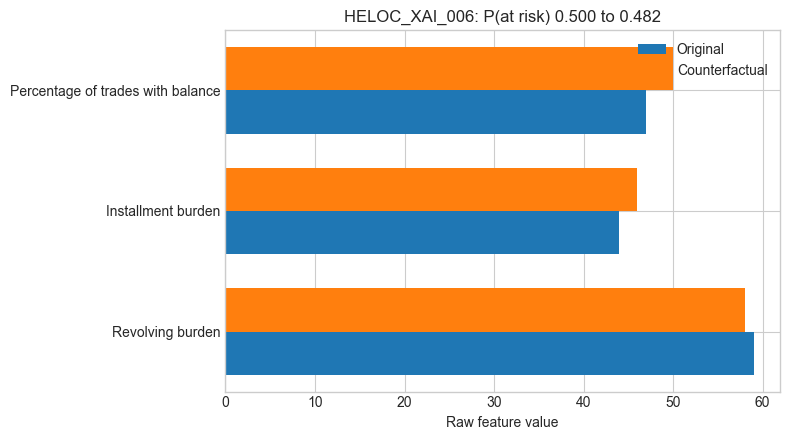

In [12]:
representative_case=None
if len(valid_cfs):
    preferred=valid_cfs[valid_cfs.case_id.eq("HELOC_XAI_001")]
    if len(preferred): representative_case="HELOC_XAI_001"
    else:
        high=xai_cases[xai_cases.case_type.eq("high-confidence positive")].case_id
        eligible_valid=valid_cfs[valid_cfs.case_id.isin(high)]
        representative_case=(eligible_valid.iloc[0].case_id if len(eligible_valid) else valid_cfs.iloc[0].case_id)
if representative_case:
    cf=valid_cfs.loc[valid_cfs.case_id.eq(representative_case)].iloc[0]; plotted=changes[(changes.case_id==representative_case)&changes.changed]
    fig,ax=plt.subplots(figsize=(8,4.5)); y=np.arange(len(plotted)); width=.36
    ax.barh(y-width/2,plotted.original_value,height=width,label="Original"); ax.barh(y+width/2,plotted.counterfactual_value,height=width,label="Counterfactual")
    ax.set_yticks(y,plotted.display_feature); ax.set_xlabel("Raw feature value"); ax.set_title(f"{representative_case}: P(at risk) {cf.original_probability:.3f} to {cf.counterfactual_probability:.3f}")
    ax.legend(); fig.tight_layout(); fig.savefig(PLOT_DIR/"heloc_dice_representative_counterfactual.png",dpi=180,bbox_inches="tight"); plt.show()
else: print("No valid counterfactual; representative plot not created.")

## 12. Metadata and integrity checks

The final checks summarize the persisted experiment and confirm that future runs use load-only mode.

In [13]:
first_counts=first_pass.generation_status.value_counts().to_dict(); retry_counts=retry_status.generation_status.value_counts().to_dict(); technical_retry_counts=technical_retry_status.generation_status.value_counts().to_dict()
metadata={
    "dataset":"mstz/heloc risk configuration","model_path":str(ARTIFACT_DIR/"xgboost_credit_model.joblib"),"preprocessor_path":str(ARTIFACT_DIR/"preprocessor.joblib"),
    "training_reference_rows":len(X_train_raw),"fixed_xai_case_count":len(xai_cases),"method":"genetic","total_CFs":TOTAL_CFS,
    "features_permitted_to_vary":MODIFIABLE_FEATURES,"actionability_terminology":"counterfactual-modifiable financial-state variable",
    "special_code_policy":"-7/-8/-9 excluded from permitted domains; a query feature in a special state remains fixed",
    "permitted_ranges":permitted_range,"first_pass_timeout_seconds":FIRST_PASS_TIMEOUT,"retry_timeout_seconds":RETRY_TIMEOUT,
    "first_pass_outcome_counts":first_counts,"retry_outcome_counts":retry_counts,"technical_retry_outcome_counts":technical_retry_counts,"technical_retry_fix":"sole-parent guard; scientific search space unchanged","valid_counterfactual_count":len(valid_cfs),
    "wrapper_maximum_probability_difference":wrapper_maximum_difference,"representative_case":representative_case,
    "model_retrained":False,"preprocessor_refitted":False,"new_split_created":False,"shap_rerun":False,"lime_rerun":False,
}
(ARTIFACT_DIR/"dice_metadata.json").write_text(json.dumps(metadata,indent=2),encoding="utf-8")
assert len(first_pass)==20 and len(final_status)==20
assert len(retry_status)==int(first_pass.generation_status.eq("timeout").sum())
assert len(changes)==len(valid_cfs)*3
if len(valid_cfs):
    assert valid_cfs.valid_counterfactual.all() and valid_cfs.special_states_preserved.all()
    assert valid_cfs.non_modifiable_features_unchanged.all() and valid_cfs.training_domain_valid.all()

print("Frozen model loaded: True")
print("Exact train rows reconstructed:",len(X_train_raw)); print("Exact test rows reconstructed:",len(X_test_raw))
print("Frozen predictions reproduced:",metric_difference<1e-12); print("XAI cases:",len(xai_cases))
print("Approved variables:",MODIFIABLE_FEATURES); print("Valid counterfactuals:",len(valid_cfs))
print("Feature-change rows:",len(changes),"expected",len(valid_cfs)*3)
print("RUN_FULL_FIRST_PASS:",RUN_FULL_FIRST_PASS); print("RUN_TIMEOUT_RETRY:",RUN_TIMEOUT_RETRY); print("RUN_TECHNICAL_RETRY:",RUN_TECHNICAL_RETRY)
print("Model retrained: False\nPreprocessor refitted: False\nNew split: False\nSHAP rerun: False\nLIME rerun: False\nDiCE searches launched in this run:",RUN_FULL_FIRST_PASS or RUN_TIMEOUT_RETRY or RUN_TECHNICAL_RETRY)

Frozen model loaded: True
Exact train rows reconstructed: 7896
Exact test rows reconstructed: 1974
Frozen predictions reproduced: True
XAI cases: 20
Approved variables: ['net_fraction_of_revolving_burden', 'net_fraction_of_installment_burden', 'percentage_trades_with_balance']
Valid counterfactuals: 8
Feature-change rows: 24 expected 24
RUN_FULL_FIRST_PASS: False
RUN_TIMEOUT_RETRY: False
RUN_TECHNICAL_RETRY: False
Model retrained: False
Preprocessor refitted: False
New split: False
SHAP rerun: False
LIME rerun: False
DiCE searches launched in this run: False


## Final observations

Review the saved outcome categories, independent validation results, and proximity values before cross-method evaluation. Search timeouts indicate only that the allocated computational budget was exceeded.